# Machine Learning Assignment 2 — Classification Models

**Dataset:** Wisconsin Diagnostic Breast Cancer (UCI Machine Learning Repository; distributed with scikit-learn)  
**Problem:** Binary classification — malignant (0) vs benign (1)  
**Dataset size:** 569 instances, 30 numeric features (satisfies the assignment minimum of 500 instances and 12 features).

This notebook implements the **five classifiers explicitly named in the assignment**. The PDF contains a wording inconsistency saying “all 6 ML models,” but its numbered algorithm list and comparison table contain five models; therefore no unlisted sixth algorithm is invented here.


In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'model' else Path.cwd()
MODEL_DIR = PROJECT_DIR / 'model'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print('Project directory:', PROJECT_DIR.resolve())

Project directory: /mnt/data/ML_Assignment_2_Project


## 1. Load and inspect the dataset

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y = data.target.copy()

df = X.copy()
df['target'] = y

print('Shape:', df.shape)
print('Number of features:', X.shape[1])
print('Target mapping: 0 = malignant, 1 = benign')
print()
print('Class distribution:')
print(y.value_counts().rename(index={0: 'malignant', 1: 'benign'}))
df.head()

Shape: (569, 31)
Number of features: 30
Target mapping: 0 = malignant, 1 = benign

Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Create a reproducible train/test split
A stratified 80/20 split preserves the class proportions. The held-out test set is exported as `test_data.csv` for the Streamlit application.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))

test_df = X_test.copy()
test_df['target'] = y_test.values
test_df.to_csv(PROJECT_DIR / 'test_data.csv', index=False)

df.to_csv(PROJECT_DIR / 'breast_cancer_wisconsin.csv', index=False)
print('Saved test_data.csv and breast_cancer_wisconsin.csv')

Training rows: 455
Test rows: 114
Saved test_data.csv and breast_cancer_wisconsin.csv


## 3. Define the classification models
Scaling is included inside pipelines for Logistic Regression, kNN, and SVM because these algorithms are sensitive to feature magnitudes. Tree-based models and Gaussian Naive Bayes are trained on the original numeric features.

In [4]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    'Decision Tree': DecisionTreeClassifier(
        random_state=RANDOM_STATE, max_depth=5, min_samples_leaf=2
    ),
    'K-Nearest Neighbors': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=7))
    ]),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE,
        class_weight='balanced', n_jobs=-1
    )
}

list(models.keys())

['Logistic Regression',
 'Decision Tree',
 'K-Nearest Neighbors',
 'Naive Bayes',
 'Random Forest']

## 4. Train models and calculate all required metrics

In [5]:
def evaluate_model(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_eval)[:, 1]
    else:
        y_score = model.decision_function(X_eval)

    return {
        'Accuracy': accuracy_score(y_eval, y_pred),
        'AUC': roc_auc_score(y_eval, y_score),
        'Precision': precision_score(y_eval, y_pred, zero_division=0),
        'Recall': recall_score(y_eval, y_pred, zero_division=0),
        'F1': f1_score(y_eval, y_pred, zero_division=0),
        'MCC': matthews_corrcoef(y_eval, y_pred)
    }

results = {}
model_files = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = evaluate_model(model, X_test, y_test)
    filename = name.lower().replace(' ', '_').replace('-', '_') + '.joblib'
    joblib.dump(model, MODEL_DIR / filename)
    model_files[name] = filename

metrics_df = pd.DataFrame(results).T
metrics_df.index.name = 'ML Model Name'
metrics_df.to_csv(PROJECT_DIR / 'metrics.csv')
metrics_df.round(4)

,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Logistic Regression,0.9825,0.9954,0.9861,0.9861,0.9861,0.9623
Decision Tree,0.9035,0.9377,0.9692,0.8750,0.9197,0.8062
K-Nearest Neighbors,0.9737,0.9884,0.9600,1.0000,0.9796,0.9442
Naive Bayes,0.9386,0.9878,0.9452,0.9583,0.9517,0.8676
Random Forest,0.9474,0.9937,0.9583,0.9583,0.9583,0.8869


## 5. Model-wise observations

In [6]:
best_f1 = metrics_df['F1'].max()
best_models = metrics_df.index[np.isclose(metrics_df['F1'], best_f1)].tolist()

observations = []
for name, row in metrics_df.iterrows():
    text = (
        f"Accuracy={row['Accuracy']:.4f}, AUC={row['AUC']:.4f}, "
        f"Precision={row['Precision']:.4f}, Recall={row['Recall']:.4f}, "
        f"F1={row['F1']:.4f}, MCC={row['MCC']:.4f}."
    )
    if row['Recall'] == metrics_df['Recall'].max():
        text += ' It achieved the highest recall on this split.'
    if np.isclose(row['F1'], best_f1):
        text += ' It achieved the highest F1 score on this split.'
    observations.append({'ML Model Name': name, 'Observation about model performance': text})

observation_df = pd.DataFrame(observations).set_index('ML Model Name')
print('Overall winner(s) by F1:', ', '.join(best_models))
observation_df

Overall winner(s) by F1: Logistic Regression


,Observation about model performance
ML Model Name,
Logistic Regression,"Accuracy=0.9825, AUC=0.9954, Precision=0.9861,..."
Decision Tree,"Accuracy=0.9035, AUC=0.9377, Precision=0.9692,..."
K-Nearest Neighbors,"Accuracy=0.9737, AUC=0.9884, Precision=0.9600,..."
Naive Bayes,"Accuracy=0.9386, AUC=0.9878, Precision=0.9452,..."
Random Forest,"Accuracy=0.9474, AUC=0.9937, Precision=0.9583,..."


## 6. Confusion matrices and classification reports


Logistic Regression
              precision    recall  f1-score   support

   Malignant     0.9762    0.9762    0.9762        42
      Benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



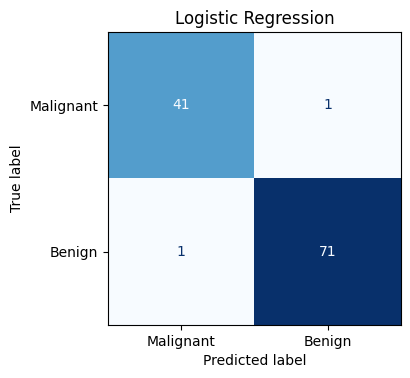


Decision Tree
              precision    recall  f1-score   support

   Malignant     0.8163    0.9524    0.8791        42
      Benign     0.9692    0.8750    0.9197        72

    accuracy                         0.9035       114
   macro avg     0.8928    0.9137    0.8994       114
weighted avg     0.9129    0.9035    0.9048       114



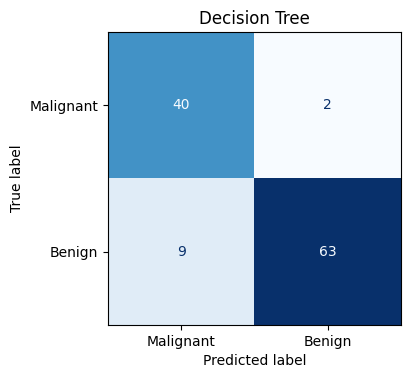


K-Nearest Neighbors
              precision    recall  f1-score   support

   Malignant     1.0000    0.9286    0.9630        42
      Benign     0.9600    1.0000    0.9796        72

    accuracy                         0.9737       114
   macro avg     0.9800    0.9643    0.9713       114
weighted avg     0.9747    0.9737    0.9735       114



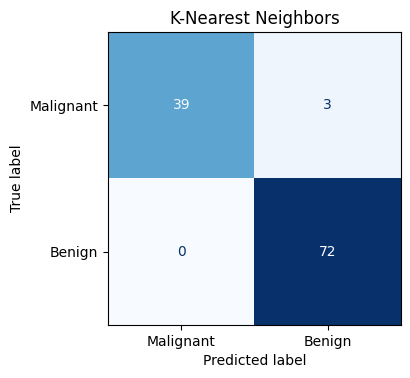


Naive Bayes
              precision    recall  f1-score   support

   Malignant     0.9268    0.9048    0.9157        42
      Benign     0.9452    0.9583    0.9517        72

    accuracy                         0.9386       114
   macro avg     0.9360    0.9315    0.9337       114
weighted avg     0.9384    0.9386    0.9384       114



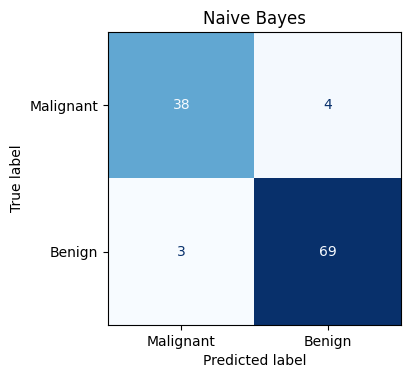


Random Forest
              precision    recall  f1-score   support

   Malignant     0.9286    0.9286    0.9286        42
      Benign     0.9583    0.9583    0.9583        72

    accuracy                         0.9474       114
   macro avg     0.9435    0.9435    0.9435       114
weighted avg     0.9474    0.9474    0.9474       114



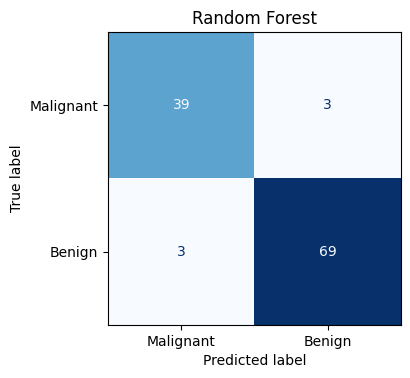

In [7]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print()
    print('=' * 80)
    print(name)
    print(classification_report(
        y_test, y_pred,
        target_names=['Malignant', 'Benign'],
        digits=4,
        zero_division=0
    ))
    fig, ax = plt.subplots(figsize=(4.5, 3.8))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Malignant', 'Benign'],
        cmap='Blues', colorbar=False, ax=ax
    )
    ax.set_title(name)
    plt.show()

## 7. Save metadata for the Streamlit application

In [8]:
metadata = {
    'dataset_name': 'Wisconsin Diagnostic Breast Cancer',
    'dataset_source': 'UCI Machine Learning Repository (also packaged in scikit-learn)',
    'n_instances': int(X.shape[0]),
    'n_features': int(X.shape[1]),
    'target_column': 'target',
    'target_mapping': {'0': 'malignant', '1': 'benign'},
    'feature_names': list(X.columns),
    'random_state': RANDOM_STATE,
    'test_size': 0.20,
    'model_files': model_files
}

(MODEL_DIR / 'metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print('Saved metadata and', len(model_files), 'trained model files.')

Saved metadata and 5 trained model files.


## 8. Final files created
The notebook creates the test CSV, metrics CSV, five serialized model files, and metadata needed by `app.py`. Run this notebook on the BITS Virtual Lab and capture one screenshot as required by the assignment.